# How to Run Calculations for Simple Molecules
**by <span style="color:darkgreen">Pasquale Pavone</span> & <span style="color:darkgreen">Caterina Cocchi</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial you will learn how to set up and execute **exciting** calculations for simple molecules such as the carbon dioxide (CO<sub>2</sub>) water (H<sub>2</sub>O), and pyridine (C<sub>5</sub>H<sub>5</sub>N) molecule. It is also shown how to calculate and visualize molecular orbitals, with explicit application to the HOMO and LUMO of carbon dioxide.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Carbon-dioxide molecule](#1)
 
* [Isolated molecules are treated as special periodic systems](#1-1)  
* [Preparation of the input file](#1-2)
* [Execute calculations](#1-3)
* [Analyze results](#1-4)
* [Exercises](#1-5)

[2. Water molecule](#2)
    
* [Exercises](#2-1)
    
[3.  Pyridine molecule](#3)
    
* [Exercises](#3-1)
 
[4.  Visualization of molecular orbitals of CO2](#4)
    
* [Visualization of the first HOMO](#4-1)
* [Visualization of the second HOMO](#4-2)
* [Visualization of the LUMO](#4-3)
* [Exercises](#4-4)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>execute.single.py</b></code>: Python script for running a single exciting calculation.
* <code><b>convert_xml2xsf.py</b></code>: Python script for converting xml to xsf files.sduring the relaxation process.
* <code><b>plot.bondlength.py</b></code>: Python visualization tool for following relative atomic coordinates of atoms during the relaxation process.
* <code><b>plot.status.py</b></code>: Python visualization tool for RMS deviations of the SCF potential as a function of the iteration number during the SCF loop.
* <code><b>plot.maxforce.py</b></code>: Python visualization tool for the maximum amplitude of the force on the atoms during relaxation.
* <code><b>plot.torque.py</b></code>: Python visualization tool for the total torque during relaxation.
* <code><b>plot.centerofmass.py</b></code>: Python visualization tool for the cartesian components of the position of the center of mass during relaxation.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Carbon-dioxide molecule</span>

The CO<sub>2</sub> molecule is a linear one with the two oxygen atoms located symmetrically with respect to the central carbon atom, as can be seen in the following figure taken from the [<span style="color:firebrick;font-weight:bold">wikipedia page of Carbon dioxide</span>](https://en.wikipedia.org/wiki/Carbon_dioxide).

<figure>
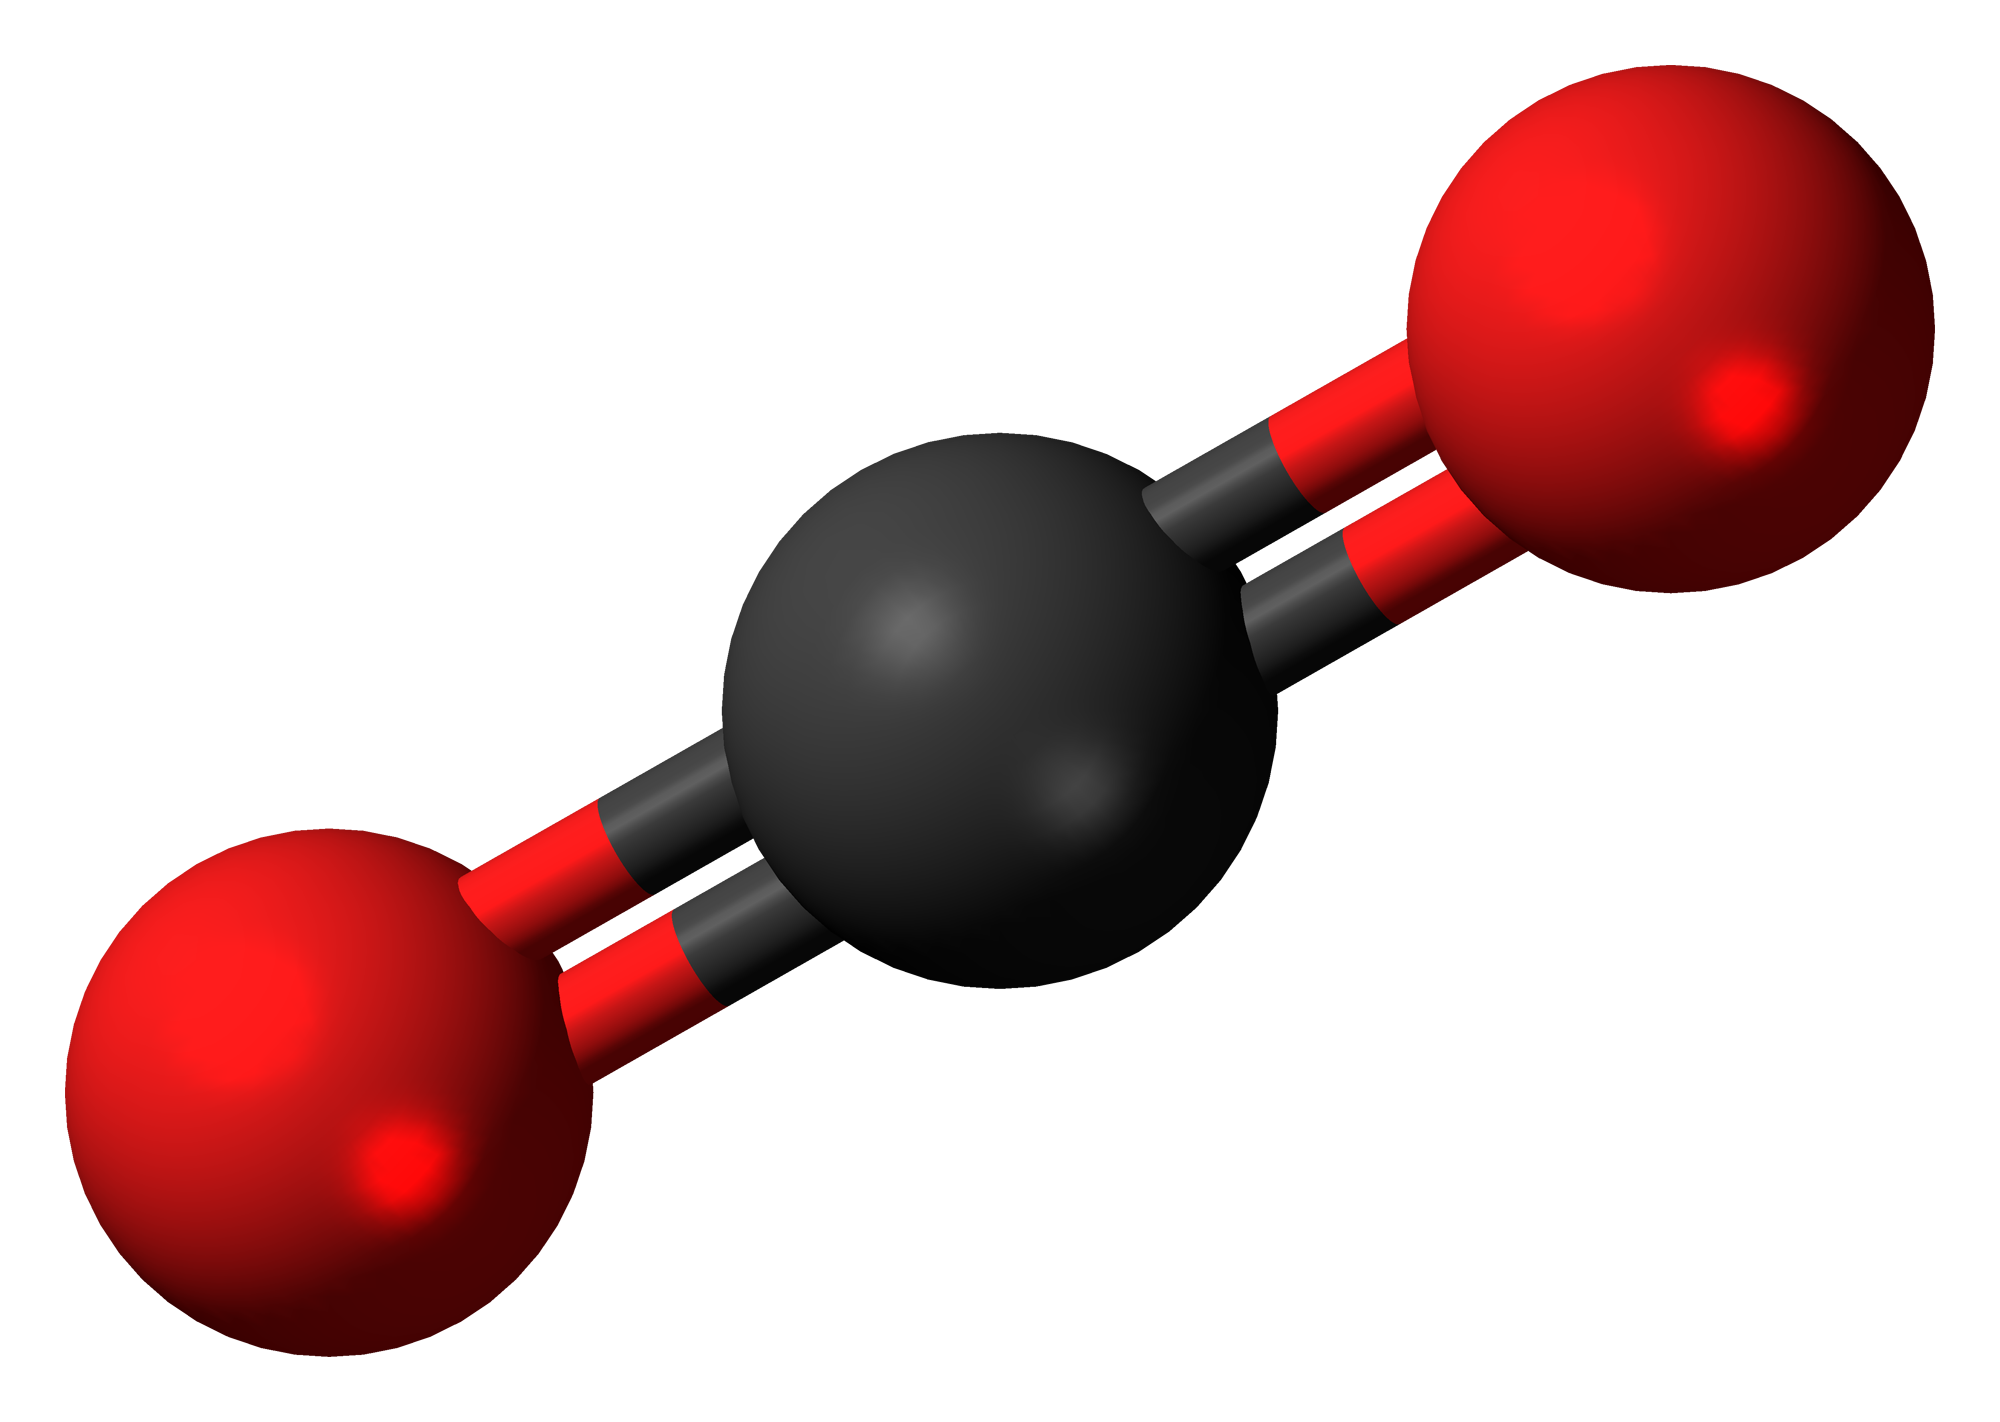
</figure>


The experimental bond lengths are

* d<sub>CO</sub> = 2.198 Bohr,
* d<sub>OO</sub> = 4.396 Bohr.

<a id='1-1'></a>
<b>i) Isolated molecules are treated as special periodic systems</b>

In order to perform the calculation, we have to let **`exciting`**' know that we would like to consider an isolated molecule with a certain atomic configuration. However, all calculations performed by **`exciting`**' assume a three-dimensional periodicity along the directions defined by the lattice vectors. Therefore, when considering a molecule one has to prepare a special three-dimensional crystal where the distances between a molecule and each of its *replicas* are **large enough** so that each molecule behaves as it would be isolated.

The procedure one has to follow in this case is illustrated in the next picture in the simplification of only two dimensions.

<figure>
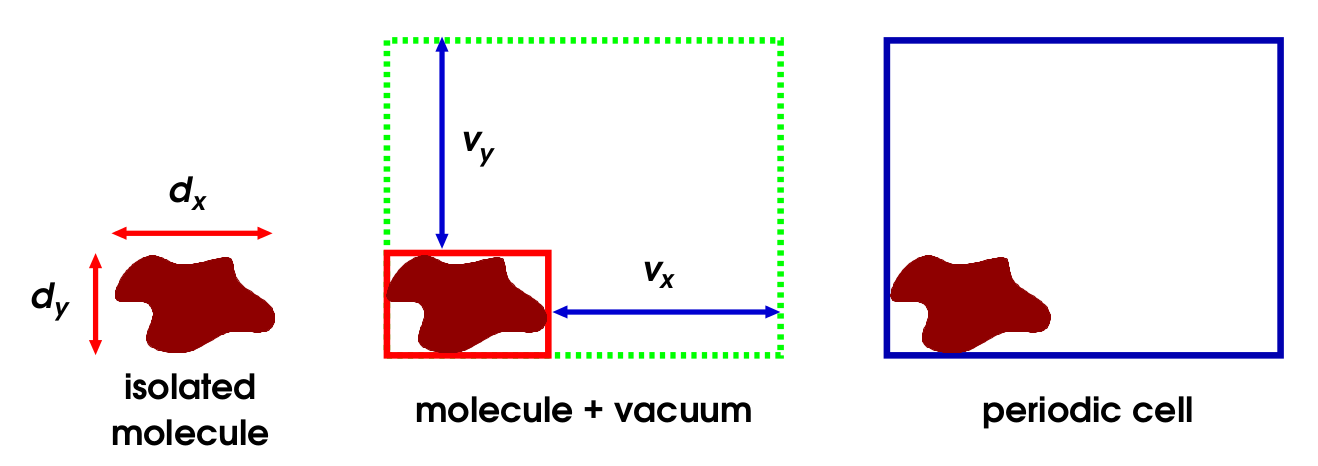
</figure>

The first thing to do is to determine the size (expressed by $dx$, $dy$, $dz$ along the three cartesian directions) of the molecule you are investigating, as illustrated in the left panel of the picture above. Next, some vacuum (expressed by $v_x$, $v_y$, $v_z$) is added, as you can see above in the middle panel. The amount of vacuum has to be chosen in such a way to prevent intermolecular interactions. Finally, a cartesian periodic cell is created with basis vectors of amplitude ($d_x+v_x$, $d_y+v_y$, $d_z+v_z$) along the corresponding cartesian axis (see right panel).

<a id='1-2'></a>
<b>ii) Preparation of the input file</b>

The first step is to create a directory for each system that you want to investigate. Thus, we will create a directory <b>CO2</b>.

In [1]:
%%bash
mkdir -p CO2

An example for an **`exciting`**' input file (<b>input.xml</b>) which is needed for the calculation of the optimized structure of the CO<sub>2</sub> molecule is given in the following.

<span class="CO2_INPUT"></span>
```xml
<input>
 
   <title>CO2 molecule</title>
 
   <structure speciespath="$EXCITINGROOT/species" cartesian="true">
      <crystal>
         <basevect> 10.0  0.0  0.0 </basevect>
         <basevect>  0.0  5.0  0.0 </basevect>
         <basevect>  0.0  0.0  5.0 </basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.0">
         <atom coord=" 0.00  0.00  0.00" lockxyz="true true true"/>
      </species>
      <species speciesfile="O.xml" rmt="1.0">
         <atom coord=" 2.50  0.00  0.00" lockxyz="false true true"/>
         <atom coord="-2.50  0.00  0.00" lockxyz="false true true"/>
      </species>
   </structure>
 
   <groundstate 
      xctype="LDA_PW"
      gmaxvr="16"
      rgkmax="4"
      outputlevel="low">
   </groundstate>
 
   <relax 
      printtorque="true"
      history="true">
   </relax>
 
</input>
```

In [2]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("how_to_run_calculations_for_simple_molecules", "CO2_INPUT")

# Write out the input as an XML file:
with open('./CO2/input.xml', "w") as fid:
    fid.write(input_str)

Some of the elements and attributes appearing in this input file should be already familiar to you from other tutorials. Here, we will discuss in detail only those elements and attributes which are significant in molecule calculations.

First, we analyze the first line of the element <code><span style="color:green">structure</span></code>.

```xml
    <structure ... cartesian="true">
```

Here, the new attribute <code><span style="color:mediumblue">cartesian</span></code> appears. If <code><span style="color:mediumblue">cartesian</span></code> is set to <code><span style="color:#ae3931">"true"</span></code> the atomic coordinates which are specified by lines like

```xml
        <atom coord=" 2.50  0.00  0.00".../>
```

are assumed to be given in <b><span style="color:red">cartesian</span></b> coordinates. This option is particularly useful when dealing with molecules.

Furthermore, the basis vectors, which define the periodic cell including the molecule and the vacuum, are taken in the most simple way to lay along the cartesian axis. The amplitude of each basis vector is chosen in such a way to accommodate the size of the molecule in its direction and the amount of vacuum which we desire to add. The basis vectors shown in our example are

```xml
        <basevect> 10.0  0.0  0.0 </basevect>
        <basevect>  0.0  5.0  0.0 </basevect>
        <basevect>  0.0  0.0  5.0 </basevect>
```

and correspond to a linear molecule of size of about 5 Bohr lying along the x axis and a vacuum of 5 Bohr along each cartesian direction.

The next new feature that can be seen in the input file is the attribute <code><span style="color:mediumblue">lockxyz</span></code> which is always located inside the <code><span style="color:green">atom</span></code> atom element.

```xml
        <atom coord=" 2.50  0.00  0.00" lockxyz="false true true"/>
```

The optional attribute <code><span style="color:mediumblue">lockxyz</span></code> is connected to the optimization of the internal degree of freedom of a system (molecule or crystal) which is performed when using the element <code><span style="color:green">relax</span></code>. In particular, if for one atom one of the three logical values which are given to <code><span style="color:mediumblue">lockxyz</span></code> is set to <code><span style="color:#ae3931">"true"</span></code>, this means that the corresponding <code><span style="color:mediumblue">cartesian</span></code> component of the considered atom <b><span style="color:red"> is kept fixed</span></b> during the optimization process. As an example, writing

```xml
         <atom coord=" 2.50  2.50  2.50" lockxyz="false false true"/>
```

means that, for this atom, the x and y cartesian coordinates are allowed to change during the relaxation, while the z component of the position vector is kept fixed. Furthermore, when considering molecules, it is always convenient to keep fixed the position of <b><span style="color:red">one</span></b> of the atoms of the molecule in order to avoid the translational motion of the molecule as a whole. We impose this condition on the central carbon atom.

```xml
      <species speciesfile="C.xml" ...>
         <atom coord=" 0.00  0.00  0.00" lockxyz="true true true"/>
      </species>
```  
 
The next important setting, visible in the input file <b>input.xml</b> is that the muffin-tin radii for the atomic species are given explicitly and assume values which are significantly smaller than the default values.

```xml
...
      <species speciesfile="C.xml" rmt="1.0">
...
      <species speciesfile="O.xml" rmt="1.0">
...
```

This is necessary due to the short bond lengths between the atoms in the molecule.

Notice that, contrary to all the crystal structures you have considered in these tutorials, the <code><span style="color:green">groundstate</span></code> element <b><span style="color:red">does not</span></b> contain explicitly the attribute <code><span style="color:mediumblue">ngridk</span></code>. This is completely equivalent to set <code><span style="color:mediumblue">ngridk</span></code> to <code><span style="color:#ae3931">"1 1 1"</span></code> as in the following example.

```xml  
   <groundstate 
      ngridk="1 1 1"
      ...
   </groundstate>    
```

This choice is necessary for dealing with a molecule for which one assumes that <b><span style="color:red">no interaction</span></b> is present between the molecule and its periodic *replicas*.

The next thing that can be noticed in the input file, is that the attribute <code><span style="color:mediumblue">rgkmax</span></code> of the <code><span style="color:green">groundstate</span></code> element has the value <code><span style="color:#ae3931">"4"</span></code>.

```xml
   <groundstate 
      ...
      rgkmax="4"
      ...
   </groundstate>
```

This value is significantly smaller than typical values used for crystals (where converged calculations require a value of <code><span style="color:mediumblue">rgkmax</span></code> around <code><span style="color:#ae3931">"7"</span></code> or <code><span style="color:#ae3931">"8"</span></code>). Due to presence of the vacuum region which reduce the number of plane waves necessary to describe the interstitial region in the [<b>LAPW method</b>](), setting <code><span style="color:mediumblue">rgkmax</span></code> to <code><span style="color:#ae3931">"4"</span></code> (or even to smaller values) is typical for molecule calculations.

The final remark concerns the attribute <code><span style="color:mediumblue">printtorque</span></code> (of the element <code><span style="color:green">relax</span></code>) which has been set to <code><span style="color:#ae3931">"true"</span></code>.

```xml
   <relax 
      printtorque="true"
      ...
   </relax>
```

At each optimization step, this setting produces in the output file <b>"INFO.OUT"</b> two lines which contain the <code><span style="color:mediumblue">cartesian</span></code> components of the center of mass and total torque, respectively. These lines should look in general like the following.

<code>...       
 Center of mass  :     0.00001466   -0.00050662    0.00000000  (cartesian)
 Total torque    :     0.00000000    0.00000000    0.00000798  (cartesian)
...                                                                       </code>

The center of mass and the total torque are well defined only when dealing with isolated systems such as those considered in this Tutorial. In particular, towards the end of the optimization run, non vanishing values for the components of the total torque (numerically, larger than about 10<sup>-3</sup> Ha) may indicate that the molecule as a whole has started to rotate or oscillate. This would prevent the relaxation to reduce the atomic forces below the desired threshold.


<a id='1-3'></a>
<b>iii) Execute calculations</b>

<b><span style="color:red">N.B.</span></b>: Set up <code><span style="color:mediumblue">$EXCITINGROOT</span></code> to the correct root directory in <code><span style="color:mediumblue">speciespath</span></code> using the command:

In [3]:
%%bash
cd CO2
python3 -m excitingscripts.setup.excitingroot
cd ..

To perform the structure optimization of the CO2 molecule you have to run the script <code><b>excitingscripts.setup.excitingroot.py</b></code> in the directory where the input file <b>input.xml</b> has been created. If you want to save the results of this run in the subdirectory <b>CO2-test-1</b> you should run as in the following.

In [ ]:
%%bash
mkdir -p CO2/CO2-test-1
cd CO2/CO2-test-1
cp ../input.xml ./
python3 -m excitingscripts.execute.single -f input.xml
cd ../../

<a id='1-4'></a>
<b>iv) Analyze results</b>

The analysis of the result of the optimization run can be visualized with the help of the scripts already introduced in [<span style="color:firebrick;font-weight:bold">Simple examples of structure optimization</span>]().

The maximum value of the force acting on the atoms can be visualized using the script <code><b>excitingscripts.plot.maxforce.py</b></code>

In [ ]:
%%bash
python3 -m excitingscripts.plot.maxforce -r CO2/CO2-test-1/

The output of this script (file <b>PLOT.png</b>) should look like the following.
<figure>
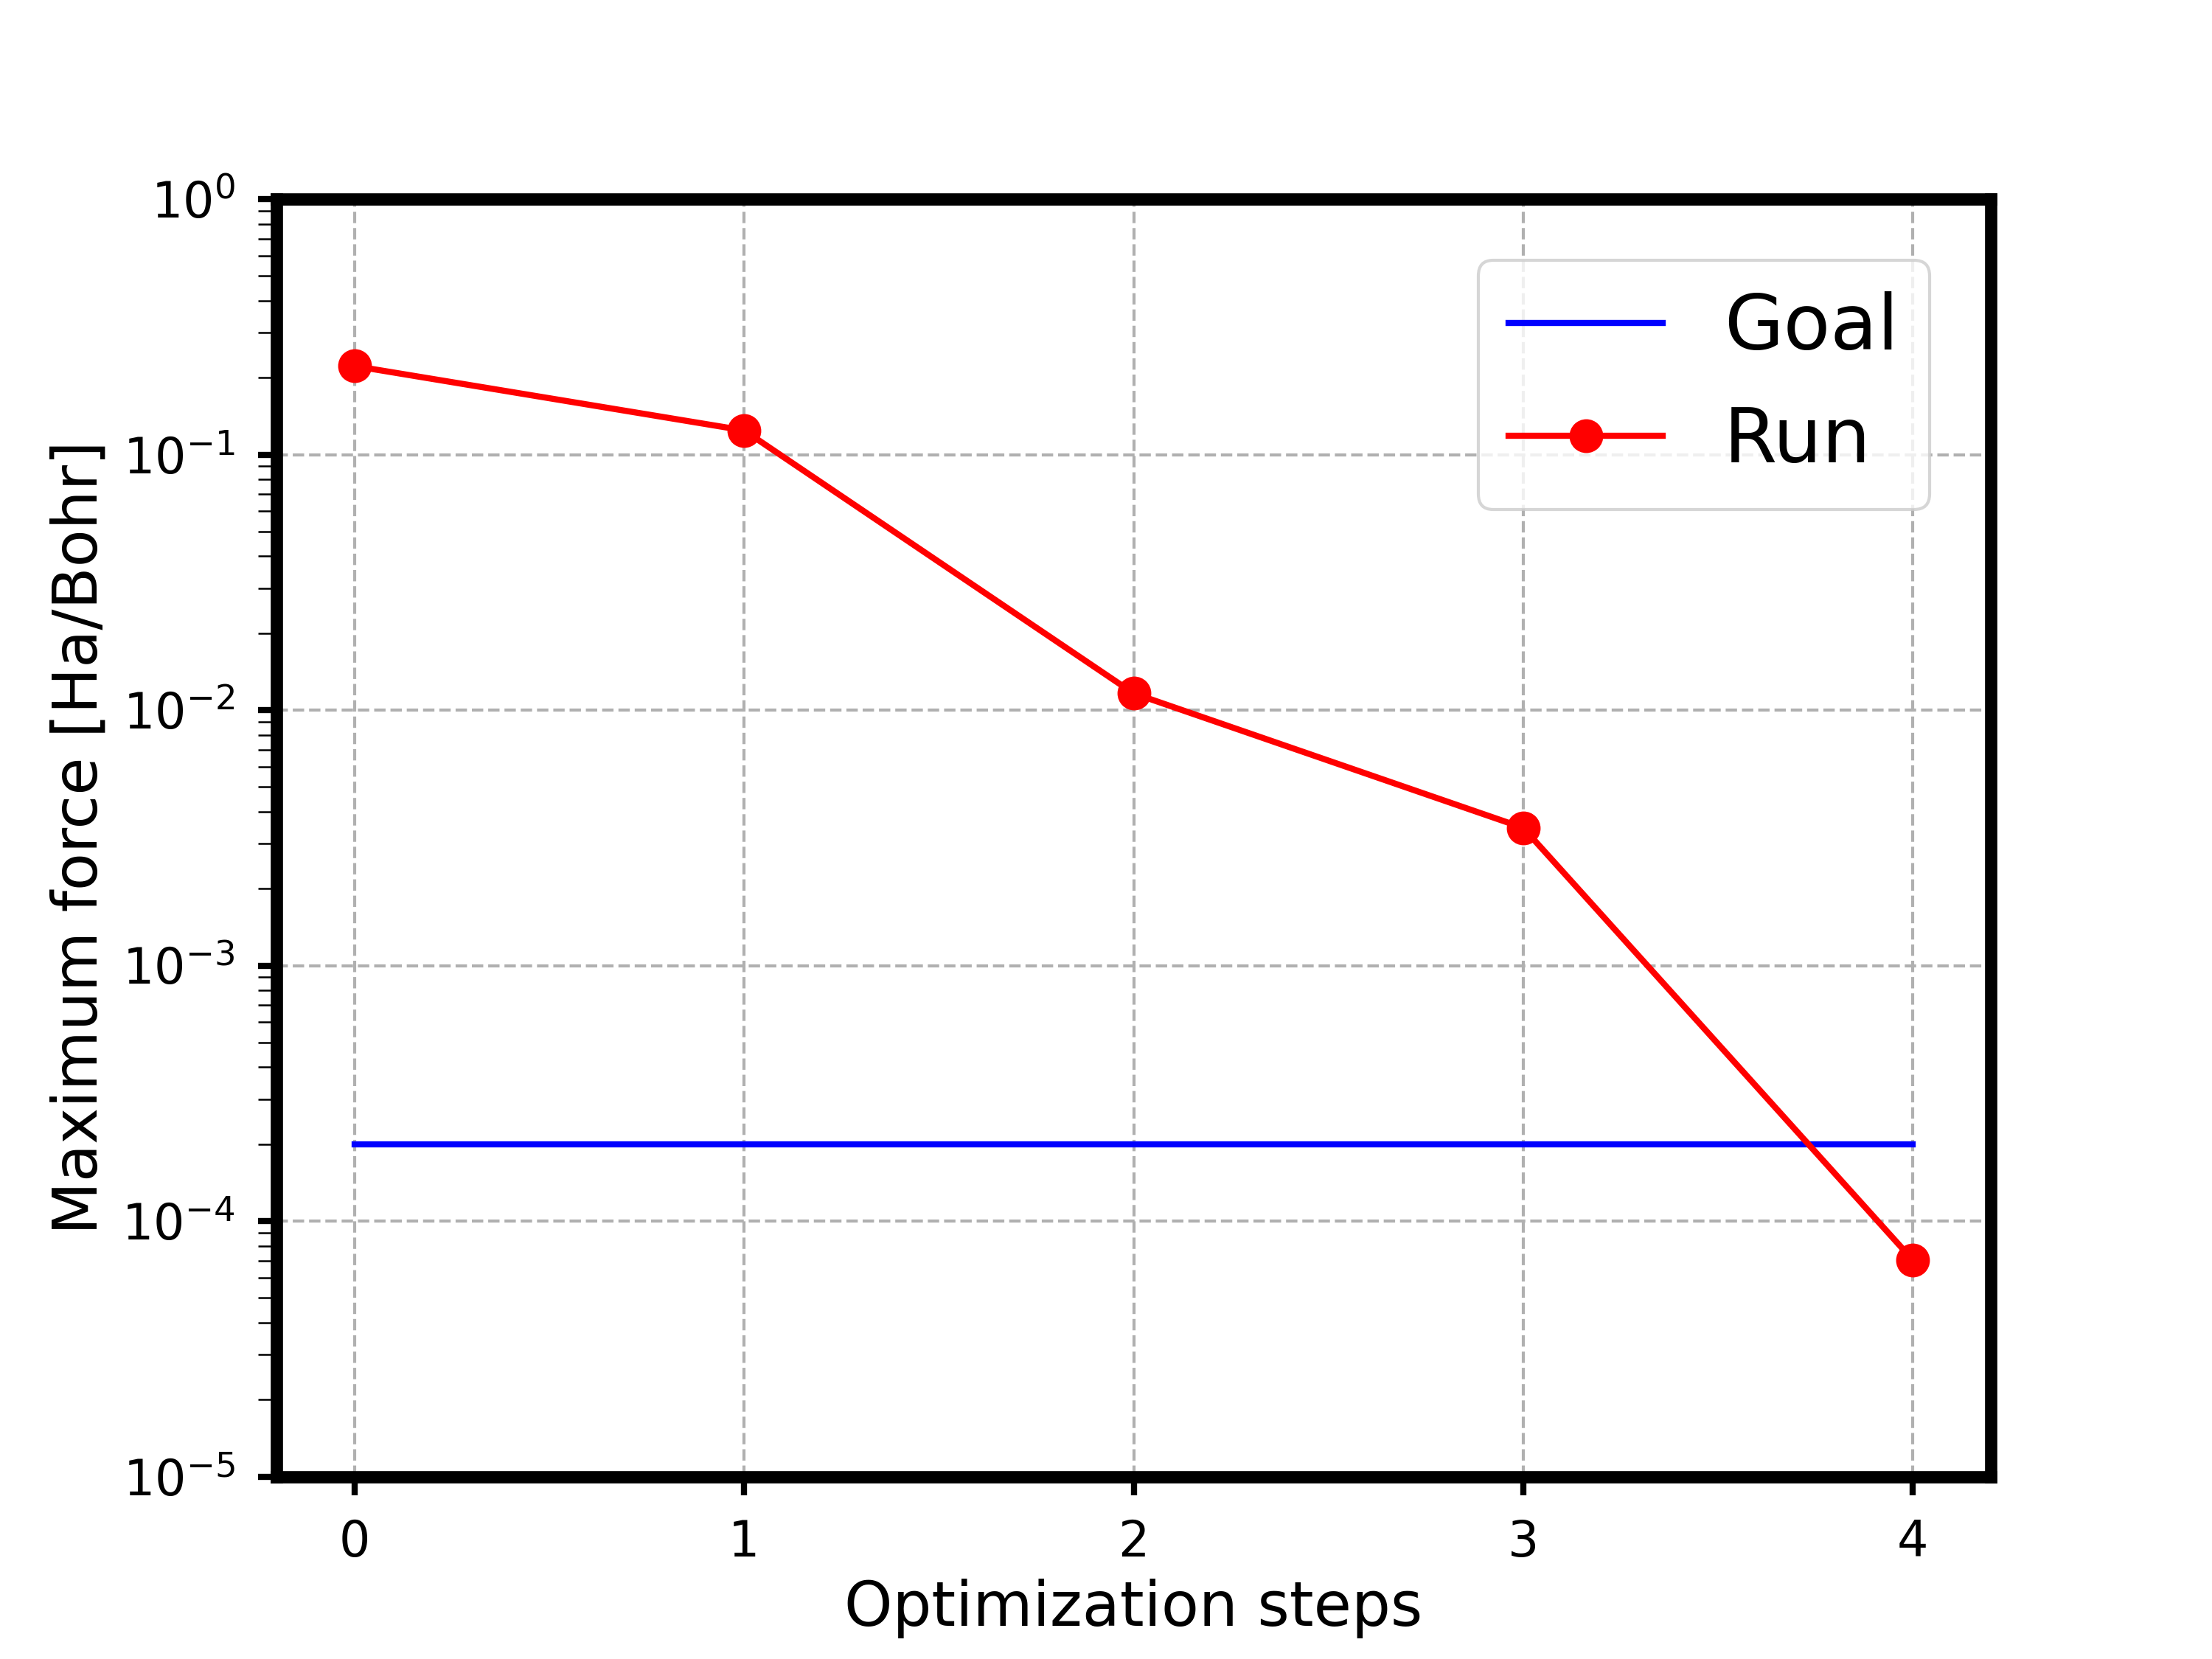</figure>

We can see that the optimization required 4 steps to reach the target minimum force.

Further information is provided using the script <code><b>excitingscripts.plot.bondlength.py</b></code>.

In [14]:
%%bash
python3 -m excitingscripts.plot.bondlength CO2/CO2-test-1 1 2

In this case, the output reproduces the bond length between atom <b>"1"</b> (the central carbon atom) and atom <b>"2"</b> (the first oxygen atom as listed in <b>input.xml</b>) and looks like
<figure>
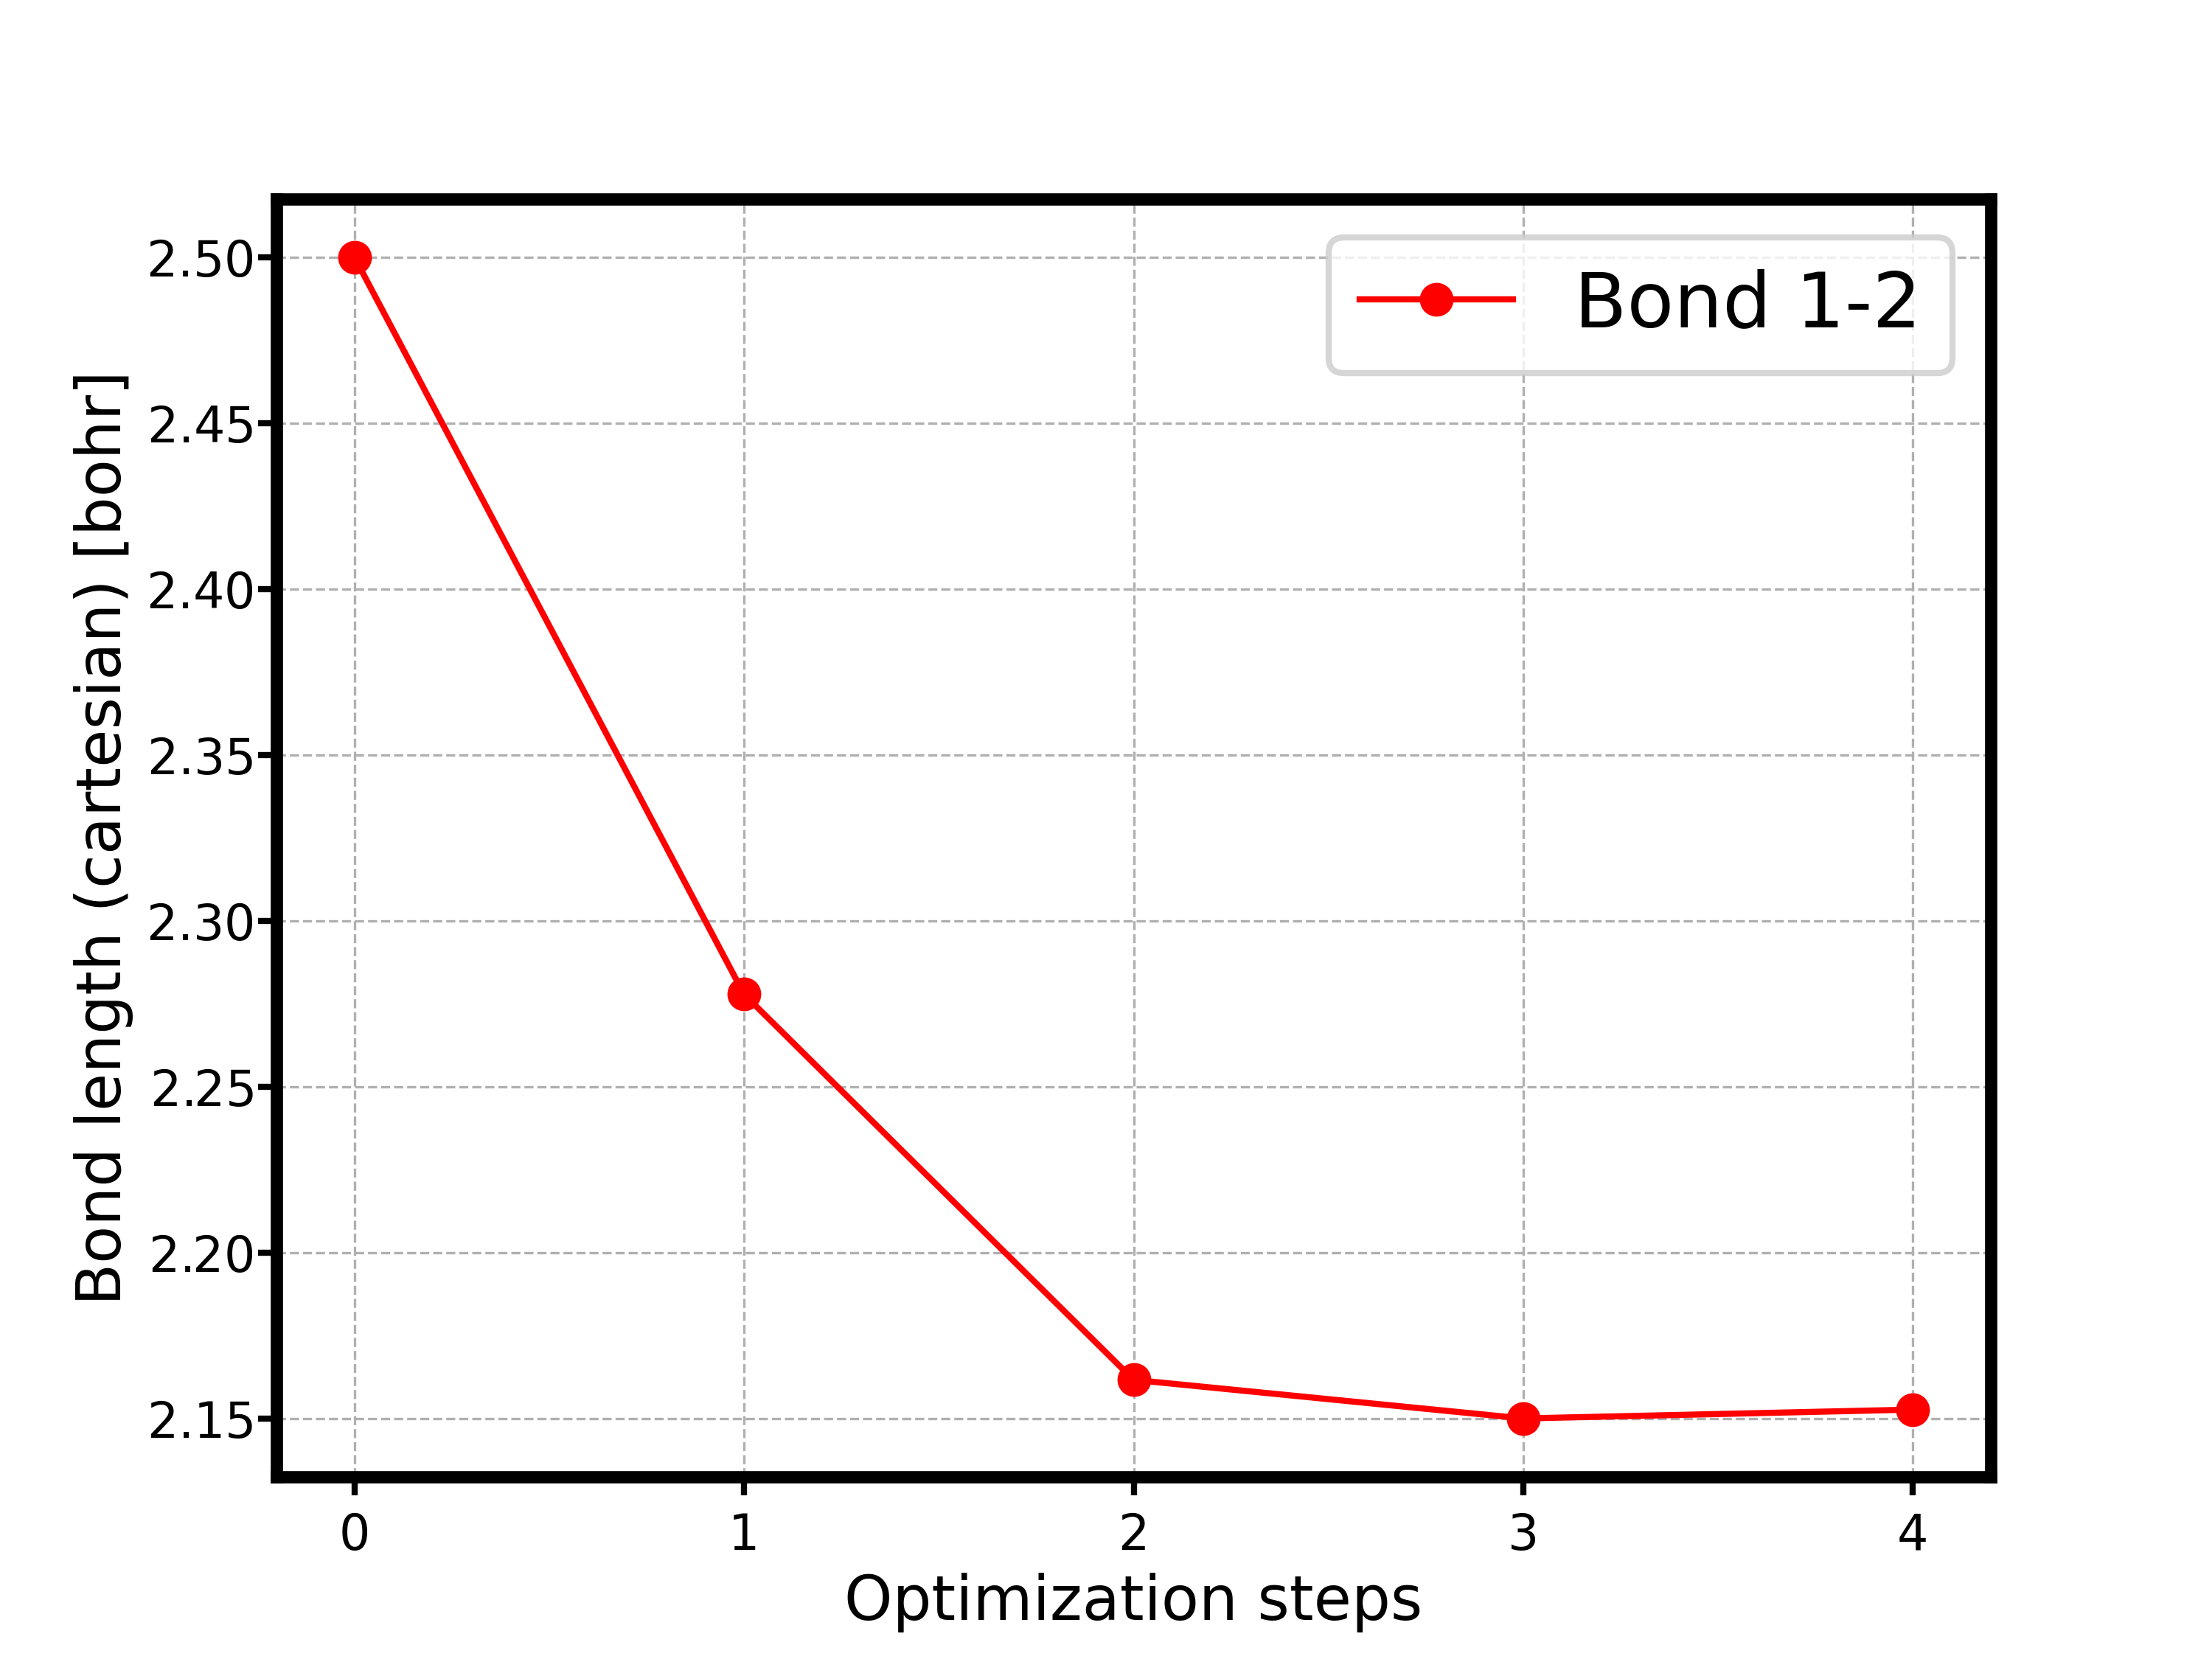
</figure>

Notice that in this case crystal axes are parallel to the cartesian directions. One can also notice that the bond length is reduced from the initial value and reaches a value slightly larger than 2.15 Bohr.

The complete information about the optimized bond lengths is found in the file <b>BONDLENGTH_OPT.OUT</b> in the <b>CO2-test-1 directory</b>. Typing

In [7]:
%%bash
cat CO2/CO2-test-1/BONDLENGTH_OPT.OUT


Distance between is =    1 (C), ia =    1 and
 is =    1 (C), ia =    1 :    0.000000000    
 is =    2 (O), ia =    1 :    2.152770757    
 is =    2 (O), ia =    2 :    2.152770757    

Distance between is =    2 (O), ia =    1 and
 is =    1 (C), ia =    1 :    2.152770757    
 is =    2 (O), ia =    1 :    0.000000000    
 is =    2 (O), ia =    2 :    4.305541513    

Distance between is =    2 (O), ia =    2 and
 is =    1 (C), ia =    1 :    2.152770757    
 is =    2 (O), ia =    1 :    4.305541513    
 is =    2 (O), ia =    2 :    0.000000000    


you should have an output on the screen similar to

<code>Distance between is =    1 (C), ia =    1 and
 is =    1 (C), ia =    1 :    0.000000000    
 is =    2 (O), ia =    1 :    2.152770757    
 is =    2 (O), ia =    2 :    2.152770757    
<br>
Distance between is =    2 (O), ia =    1 and
 is =    1 (C), ia =    1 :    2.152770757    
 is =    2 (O), ia =    1 :    0.000000000    
 is =    2 (O), ia =    2 :    4.305541513    
<br>
Distance between is =    2 (O), ia =    2 and
 is =    1 (C), ia =    1 :    2.152770757    
 is =    2 (O), ia =    1 :    4.305541513    
 is =    2 (O), ia =    2 :    0.000000000 </code>
 
 Therefore, the calculated bond lengths are

* d<sub>CO</sub> = 2.153 Bohr,
* d<sub>OO</sub> = 4.306 Bohr.

<a id='1-5'></a>
<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Exercise</b></span>

* Perform the optimization of the CO2 molecule starting from a planar configuration by setting initial coordinates and the attribute <code><span style="color:mediumblue">lockxyz</span></code> of the two oxygen atoms to the following (<span style="color:red;font-weight:bold">Notice</span>: in comparison to the previous <b>input.xml</b>, the <span style="color:red;font-weight:bold">lock on the y component has been deleted!</span>).
    
```xml
        <species speciesfile="O.xml" rmt="1.0">
            <atom coord=" 2.50  0.50  0.00" lockxyz="false false true"/>
            <atom coord="-2.50  0.50  0.00" lockxyz="false false true"/>
        </species>
```
 
* Investigate the dependence of the relaxed structure on the amount of vacuum used in the calculation. Try both increasing and decreasing the value used in the example.
    
* Investigate the dependence of the relaxed structure on the value of the attribute <code><span style="color:mediumblue">rgkmax</span></code>.
    
* Change the initial configuration (using low symmetry displacements) as in the following and perform again the optimization in the directory <b>CO2-test-2</b>.
    
```xml
        <species speciesfile="O.xml" rmt="1.0">
            <atom coord=" 2.45  0.05  0.00" lockxyz="false false true"/>
            <atom coord="-2.55 -0.05  0.00" lockxyz="false false true"/>
        </species>    
``` 
    
* Concerning the results in <b>CO2-test-2</b>. How long does it take to run the optimization in this case? Why?
    
* Have a look to the behavior of the total torque during the optimization run using the script <code><b>excitingscripts.plot.torque.py</b></code>. If results of this optimization run are in the directory <b>CO2-test-2</b> write
    
    <code>python3 -m excitingscripts.plot.torque CO2-test-2</code>

* By considering the total torque, compare the results of the runs <b>CO2-test-1</b> and <b>CO2-test-2</b>. Why are they different?

* Have a look to the behaviour of the position of the center of mass during the optimization run using the script <code><b>excitingscripts.plot.centerofmass.py</b></code>. If results of this optimization run are in the directory <b>CO2-test-2</b> write
    
    <code>python3 -m excitingscripts.plot.centerofmass CO2-test-2</code>
</div>

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Water molecule</span>

The H2O molecule is a planar one with the two hydrogen atoms located symmetrically with respect to the central oxygen atom, as can be seen in the following figure taken from the [<span style="color:firebrick;font-weight:bold">wikipedia page of water</span>](https://en.wikipedia.org/wiki/Water).

<figure>
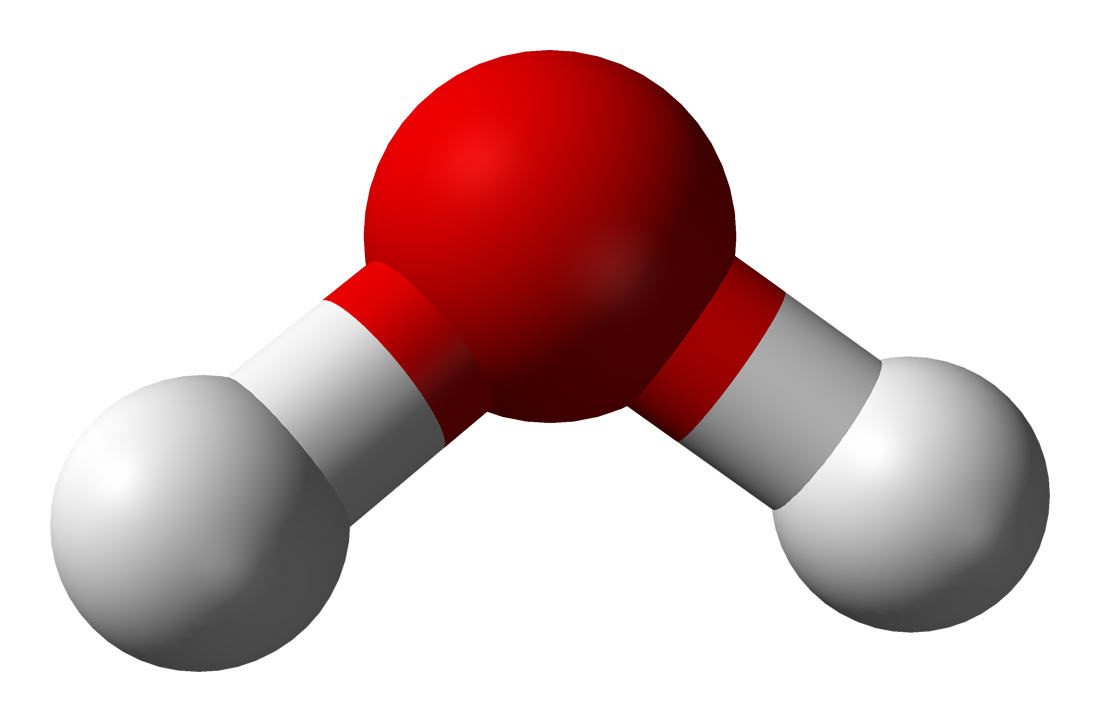
</figure>

The experimental bond lengths are

* d<sub>HO</sub> = 1.811 Bohr,
* d<sub>HH</sub> = 2.863 Bohr.

The experimental value of the HOH angle is

$\theta$<sub>HOH</sub>= 104.45 degrees

Also in this case, the first step is to create a new directory for the system that you want to investigate. Thus, we will create a directory <b>H2O</b>.

In [5]:
%%bash 
mkdir -p H2O

An example of input file (<b>input.xml</b>) for the optimization of the atomic structure of the water molecule is the following.

<span class="H2O_INPUT"></span>
```xml
<input>
 
   <title>Water molecule</title>
 
   <structure speciespath="$EXCITINGROOT/species" cartesian="true">
      <crystal>
         <basevect> 10.0   0.0  0.0 </basevect>
         <basevect>  0.0  10.0  0.0 </basevect>
         <basevect>  0.0   0.0  5.0 </basevect>
      </crystal>
      <species speciesfile="O.xml" rmt="1.0">
         <atom coord="0.00  0.00  0.00" lockxyz="true  true  true"/>
      </species>
      <species speciesfile="H.xml" rmt="0.7">
         <atom coord="2.50  0.50  0.00" lockxyz="false false true"/>
         <atom coord="0.50  2.50  0.00" lockxyz="false false true"/>
      </species>
   </structure>
 
   <groundstate 
      xctype="LDA_PW"
      gmaxvr="16"
      rgkmax="3"
      outputlevel="low">
   </groundstate>
 
   <relax
      printtorque="true"
      history="true">
    </relax>
 
</input>
```

In [6]:
input_str = get_input_xml_from_notebook("how_to_run_calculations_for_simple_molecules", "H2O_INPUT")

# Write out the input as an XML file:
with open('./H2O/input.xml', "w") as fid:
    fid.write(input_str)

Replace in the <b>input.xml</b> the string <code><span style="color:mediumblue">$EXCITINGROOT</span></code> by the actual value of the corresponding environment variable.

In [7]:
%%bash
cd H2O
python3 -m excitingscripts.setup.excitingroot
cd ..

<a id='2-1'></a>
<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Excercise</b></span>

* Try to analyze this input file in light of the experience gained with the previous molecule.
    
* Perform the relaxation calculation.
    
* Increase and decrease the vacuum around the molecule (try each direction independently), what happens? (<b>Hint</b>: use the visualization tool <code><b>excitingscripts.plot.status.py</b></code> in order to follow the convergence towards the targets for the <b>SCF</b> cycles.) 
    
* Change the initial configuration (allowing for low symmetry displacements) and perform again the optimization.
    
* Use different values of the attribute <code><span style="color:green">method</span></code> of the element <code><span style="color:green">relax</span></code> for the structure optimization.

* Perform the convergence study of the optimized structure as a function of the value of the parameter <code><span style="color:mediumblue">rgkmax</span></code>.
</div>

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Pyridine molecule</span>

Pyridine is a basic organic compound with the chemical formula C5H5N with an atomic structure similar to benzene, as can be seen in the following figure taken from the  [<span style="color:firebrick;font-weight:bold">wikipedia page of Pyridine</span>](http://en.wikipedia.org/wiki/Pyridine).

<figure>
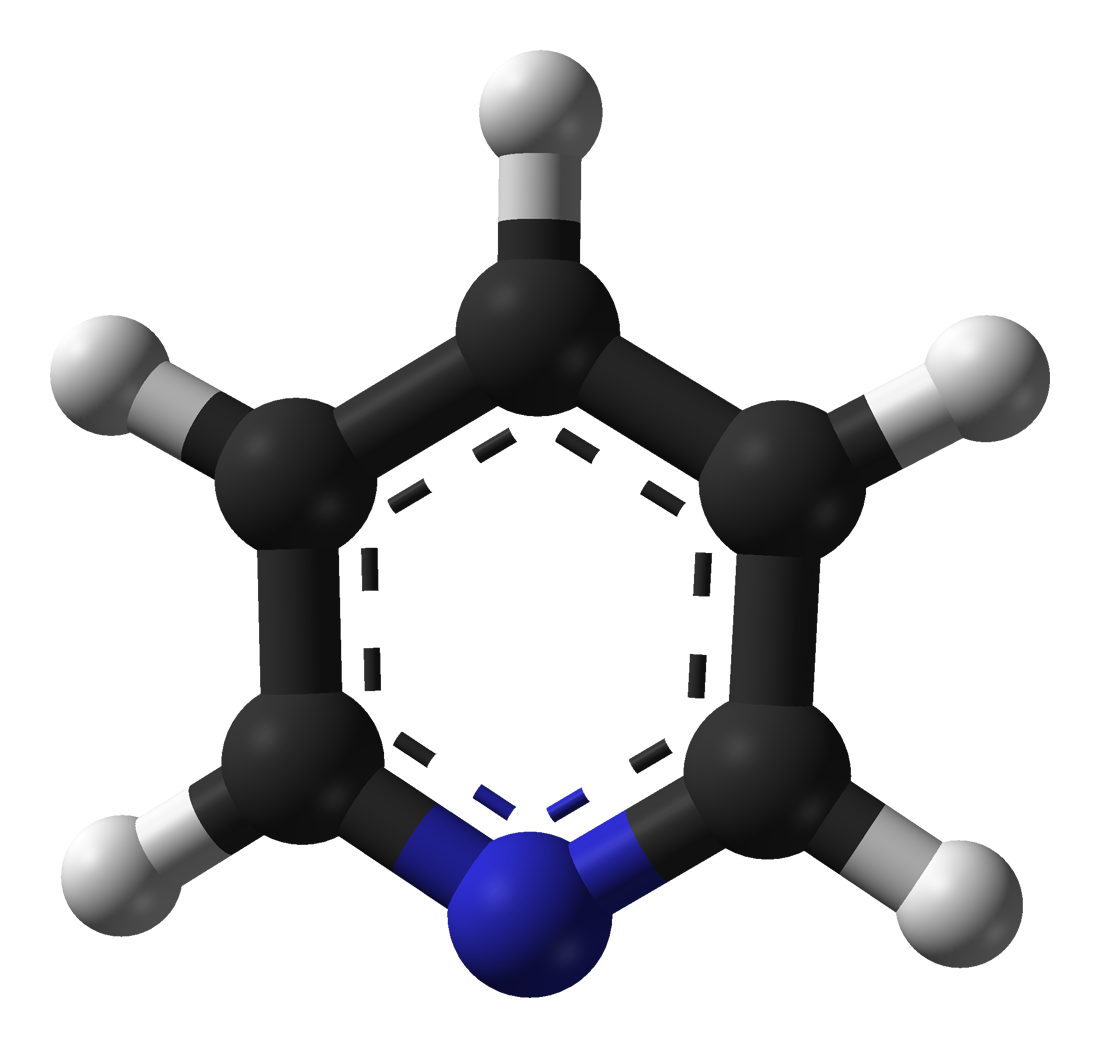
</figure>

In [11]:
%%bash 
mkdir -p Pyridine

Create a directory <b>Pyridine</b>. An example of input file (<b>input.xml</b>) for the optimization of the atomic structure of the pyridine molecule is the following.

<span class="PYRIDINE_INPUT"></span>
```xml
<input>
 
   <title>Pyridine</title>
 
   <structure speciespath="$EXCITINGROOT/species" cartesian="true">
      <crystal>
         <basevect> 14.0   0.0  0.0 </basevect>
         <basevect>  0.0  14.0  0.0 </basevect>
         <basevect>  0.0   0.0  5.0 </basevect>
      </crystal>
      <species speciesfile="N.xml" rmt="1.05">
         <atom coord=" 0.00  0.00  0.00" />
      </species>
      <species speciesfile="C.xml" rmt="1.05">
         <atom coord="-2.18  1.30  0.00" />
         <atom coord="-2.25  3.99  0.00" />
         <atom coord=" 0.00  5.25  0.00" />
         <atom coord=" 2.25  3.99  0.00" />
         <atom coord=" 2.18  1.30  0.00" />
      </species>
      <species speciesfile="H.xml" rmt="0.9">
         <atom coord="-3.93  0.10  0.00" />
         <atom coord="-4.03  5.27  0.00" />
         <atom coord=" 0.00  7.67  0.00" />
         <atom coord=" 4.03  5.27  0.00" />
         <atom coord=" 3.93  0.10  0.00" />
      </species>
   </structure>
 
   <groundstate 
      xctype="LDA_PW"
      gmaxvr="16"
      rgkmax="3.0">
   </groundstate>
 
   <relax 
      printtorque="true"
      history="true">
   </relax>
 
</input>
```

In [2]:
input_str = get_input_xml_from_notebook("how_to_run_calculations_for_simple_molecules", "PYRIDINE_INPUT")

# Write out the input as an XML file:
with open('./Pyridine/input.xml', "w") as fid:
    fid.write(input_str)

Replace in the <b>input.xml</b> the string <code><span style="color:mediumblue">$EXCITINGROOT</span></code> by the actual value of the corresponding environment variable.

In [14]:
%%bash
cd Pyridine
python3 -m excitingscripts.setup.excitingroot 
cd ..

<a id='3-1'></a>
<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Exercise</b></span>

* Perform similar investigations as for the other molecules.
</div>

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Visualization of molecular orbitals of CO<sub>2</sub></span>

In this section, we will learn how to plot molecular orbitals (<b>MOs</b>). More specific details about visualization tools available in <code><b>exciting</b></code> are reported in the tutorial **<span style="color:firebrick;font-weight:bold">How to visualize Kohn-Sham states</span>**. As a test example, we will consider here the CO<sub>2</sub> molecule. Hence, we can refer to the directory created for the runs described in <span style="color:red;font-weight:bold">Section 1</span>.

In [38]:
%%bash
mkdir -p CO2/HOMO_1



In order to create a <b>3D</b> plot of the <b>MO</b> isosurfaces, we need to perform a ground-state calculation, which includes the elements <code><span style="color:green">properties</span></code> and <code><span style="color:green">wfplot</span></code> (see **<span style="color:firebrick;font-weight:bold">How to visualize Kohn-Sham states</span>**). The input file we are going to use looks like the following:

<span class="MO_CO2_INPUT"></span>
```xml
<input>
 
   <title>CO2 molecule: Plot example</title>
 
   <structure speciespath="$EXCITINGROOT/species" cartesian="true">
      <crystal>
         <basevect> 10.0  0.0  0.0 </basevect>
         <basevect>  0.0  5.0  0.0 </basevect>
         <basevect>  0.0  0.0  5.0 </basevect>
      </crystal>
    <species speciesfile="C.xml" rmt="1.0">
      <atom coord=" 0.00000  0.0  0.0" />
    </species>
    <species speciesfile="O.xml" rmt="1.0">
      <atom coord=" 2.15277  0.0  0.0" />
      <atom coord="-2.15277  0.0  0.0" />
    </species>
   </structure>
 
   <groundstate 
      xctype="LDA_PW"
      gmaxvr="16"
      rgkmax="4"
      outputlevel="low">
   </groundstate>
 
   <properties>
      <wfplot>
         <kstlist>
            <pointstatepair>1 8</pointstatepair>
         </kstlist>
         <plot3d>
            <box grid="40 40 40">
               <origin coord="-0.5 -0.5 -0.5"/>
               <point  coord=" 0.5 -0.5 -0.5"/>
               <point  coord="-0.5  0.5 -0.5"/>
               <point  coord="-0.5 -0.5  0.5"/>
            </box>
         </plot3d>
      </wfplot>
   </properties>
 
</input>
```

In [1]:
input_str = get_input_xml_from_notebook("how_to_run_calculations_for_simple_molecules", "MO_CO2_INPUT")

# Write out the input as an XML file:
with open('./CO2/HOMO_1/input.xml', "w") as fid:
    fid.write(input_str)

Please notice that in the <code><span style="color:green">structure</span></code> element we replaced the atomic positions given in the input file in <span style="color:red;font-weight:bold">Section 1</span>, with the <span style="color:blue;font-weight:bold">optimized positions</span> obtained from the relaxation performed in the same section. As usual, before running any calculation, replace in the <b>input.xml</b> the string <code><span style="color:mediumblue">$EXCITINGROOT</span></code> by the actual value of the corresponding environment variable.

In the input file shown above, the element <code><span style="color:green">wfplot</span></code> inside <code><span style="color:green">properties</span></code> triggers the calculation of the <b>MO</b>. <code><span style="color:green">wfplot</span></code> includes the <code><span style="color:green">plot3D</span></code> subelement, which in turn enables the <b>3D</b> visualization of the orbital. The state which one wants to plot is defined by the two elements <code><span style="color:green">kstlist</span></code> and <code><span style="color:green">pointstatepair</span></code>. Inside the element <code><span style="color:green">pointstatepair</span></code> a pair with <b>k</b>-point (first integer index) and eigenvalue (second integer index) number must be specified. As we are dealing here with an isolated molecule, only <span style="color:red;font-weight:bold">1</span> <b>k</b>-point is present, therefore, the first index is always <span style="color:red;font-weight:bold">1</span>  for molecules. The second index, related to the eigenvalue labeling, is chosen as the highest occupied <b>MO</b> (<b>HOMO</b>), which corresponds to <span style="color:red;font-weight:bold">8</span> in the CO<sub>2</sub> molecule, as indicated in the file <b>EIGVAL.OUT</b>, where a map of eigenvalues is stored. Occupied (unoccupied) energy levels are identified by a nonvanishing (vanishing) number in the neighboring column. Kohn-Sham states with the same energy are degenerate. In particular, we notice that the <b>HOMO</b> of the CO<sub>2</sub> molecule is doubly degenerate.

Additional elements are <code><span style="color:green">box</span></code>, <code><span style="color:green">origin</span></code>, and <code><span style="color:green">point</span></code>. The element <code><span style="color:green">box</span></code> is specified by the attribute <code><span style="color:mediumblue">grid</span></code>, which defines the quality of the plot: The larger number of points in this mesh, the more resolved the resulting plot. <span style="color:red;font-weight:bold">Be aware</span> that the increase in the number of grid points impacts the computational costs! The elements <code><span style="color:green">origin</span></code> and <code><span style="color:green">point</span></code> allow us to define, respectively, the origin and the vectors spanning the space region where the squared norm wave function is calculated. The values of the attributes <code><span style="color:mediumblue">coord</span></code> are expressed in lattice coordinates and are chosen here in order to correctly place the orbital with respect to the atomic positions.

<a id='4-1'></a>
<b>i) Visualization of the first HOMO</b>

We now run the calculation as follows:

In [2]:
%%bash
cd CO2/HOMO_1
python3 -m excitingscripts.setup.excitingroot 
python3 -m excitingscripts.execute.single -f input.xml
cd ../../

When the run is completed, move to the newly created directory <b>HOMO_1</b>. Inside this directory, we find the file <b>WF3D.xml</b> where the <b>MO</b> is stored. We are going to visualize it with <b>XCrySDen</b>. As a first step, we transform <b>WF3D.xml</b> into a <b>xsf</b> file, by running the following template:

In [13]:
%%bash
cd CO2/HOMO_1
python3 -m excitingscripts.convert_xml2xsf -d 3D -f WF3D.xml
cd ../../

In order to visualize also the underlying structure of the molecule, we transform the atomic coordinates of the input file into a <b>xsf</b> file:

In [14]:
%%bash
cd CO2/HOMO_1
python3 -m excitingscripts.convert_xml2xsf -d 3D -f input.xml
cd ../../

Finally, we merge the two files as follows:

In [15]:
%%bash
cd CO2/HOMO_1
cat input.xsf WF3D.xsf > HOMO_1.xsf
cd ../../

Applying the procedure reported in [<span style="color:firebrick;font-weight:bold">How to visualize Kohn-Sham states</span>]() for the visualization of <b>xsf</b> files using <b>XCrySDen</b>, we can now plot the isosurface of the probability density of the <b>HOMO</b>.

In [16]:
%%bash
cd CO2/HOMO_1
xcrysden --xsf HOMO_1.xsf >/dev/null 2>&1 &
cd ../../

<hr style="border:1px solid #DDD"> </hr>
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ See here the complete procedure to visualize 3D-plots in xsf format using XCrySDen</span></strong> 
    
</summary>    
    
After running the previous command a <b>XCrySDen</b> window will appear on the screen. If you want to visualize the isosurface, use the following procedure:

1. Press on the main window <span style="color:blue;font-weight:bold">Tools -> Data Grid</span>. A new window appears.
2. Press <b>OK</b>: The previous window will disappear and a new window will appear with the control panel of the data grid to be plotted.
3. In the middle of the left column a box appears, indicating <span style="color:blue;font-weight:bold">Minimum grid value, Maximum grid value,</span> and <span style="color:blue;font-weight:bold">Isovalue</span> next to an empty box. In this box the user has to type the isovalue with which the isosurface is to be plotted. As a rule of thumb, 10% of the <span style="color:blue;font-weight:bold">Maximum grid value</span> is a reasonable value. Type the isovalue and press the <span style="color:blue;font-weight:bold">Submit</span> button on the bottom right of the window. The isosurface will now appear on the main window.
</details>  

<hr style="border:1px solid #DDD"> </hr>   

Using an isovalue one order of magnitude smaller than the maximum value, the obtained plot should be similar to the following one:
<figure>
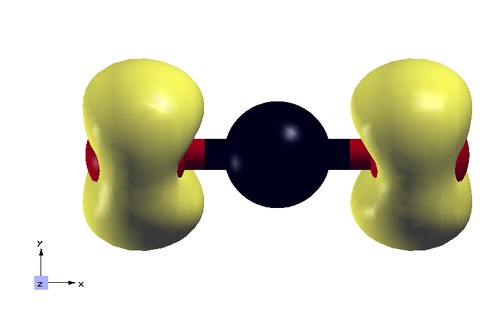
</figure>

From this plot we observe that the <b>HOMO</b> of CO<sub>2</sub> is correctly localized on the oxygen atoms of the molecule.

<a id='4-2'></a>
<b>ii) Visualization of the second HOMO</b>

As we noticed already from the file <b>EIGVAL.OUT</b> that the molecule CO<sub>2</sub> has a doubly degenerate <b>HOMO</b>, we now plot the Kohn-Sham state corresponding to index <span style="color:red;font-weight:bold">7</span> in the file <b>EIGVAL.OUT</b>. To do so, we first move to the parent directory. Here, we modify inside the existing file <b>input.xml</b> the second index in the element <code><span style="color:green">pointstatepair</span></code> as follows:

```xml
...
         <kstlist>
            <pointstatepair>1 7</pointstatepair>
         </kstlist>
...
```

In [7]:
%%bash 
mkdir -p CO2/HOMO_2

In [8]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingPropertiesInput

parsed_input = ExcitingInputXML.from_xml("./CO2/HOMO_1/input.xml")

# Defining properties with new kstlist
properties= {'wfplot': {'kstlist': [[1, 7]],
  'plot3d': {'box': {'grid': [40, 40, 40],
    'point': [{'coord': [0.5, -0.5, -0.5]},
     {'coord': [-0.5, 0.5, -0.5]},
     {'coord': [-0.5, -0.5, 0.5]}],
    'origin': {'coord': [-0.5, -0.5, -0.5]}}}}}

parsed_input.properties = ExcitingPropertiesInput(**properties)

parsed_input.write("./CO2/HOMO_2/input.xml")

Now we run again <b>exciting</b> using the command

In [9]:
%%bash
cd CO2/HOMO_2
python3 -m excitingscripts.execute.single 
cd ../../

and, after the run is completed, move to the directory <b>HOMO_2</b>. As a result of the calculation run, another file <b>WF3D.xml</b> is generated. Using the same procedure described above we can generate the file <b>HOMO_2.xsf</b>, which can be visualized using <b>XCrySDen</b>. 

In [1]:
%%bash
cd CO2/HOMO_2
python3 -m excitingscripts.convert_xml2xsf -d 3D -f WF3D.xml
python3 -m excitingscripts.convert_xml2xsf -d 3D -f input.xml
cat input.xsf WF3D.xsf > HOMO_2.xsf
xcrysden --xsf HOMO_2.xsf >/dev/null 2>&1 &
cd ../../

The obtained plot should be similar to the following one:
<figure>
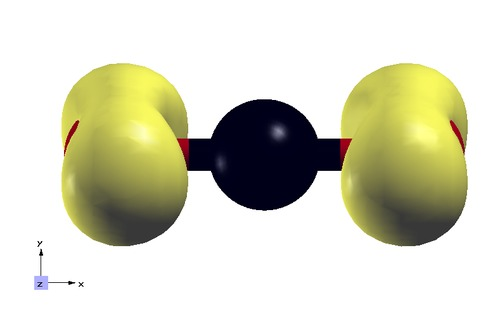
</figure>

The degeneracy of the two <b>HOMO</b> orbitals is evident: The shape of the isosurface is the same, while its orientation with respect to the coordinate system is rotated by 90 degrees.

<hr style="border:1px solid #DDD"> </hr>
<span style="color:red;font-weight:bold">Please notice that</span>, , due to the degeneracy of the <b>HOMO_1</b> and <b>HOMO_2</b> orbitals, their plots could appear different from what is shown here. However, the difference will consist in the application of an artificial rotation of both orbitals around the axis of the molecule. Of course, this difference has no effect on the physical properties of the molecule.

<hr style="border:1px solid #DDD"> </hr>

<a id='4-3'></a>
<b>iii) Visualization of the LUMO</b>

Finally, we also calculate and plot the lowest unoccupied <b>MO</b> (<b>LUMO</b>) of CO<sub>2</sub>. The procedure is now known. The LUMO is non degenerate and is labeled with the index <span style="color:red;font-weight:bold">9</span> in the file <b>EIGVAL.OUT</b>. We modify the input file accordingly

```xml
...
         <kstlist>
            <pointstatepair>1 9</pointstatepair>
         </kstlist>
...
```
and run again <b>exciting</b>:

In [10]:
%%bash 
mkdir -p CO2/LUMO

In [3]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingPropertiesInput

parsed_input = ExcitingInputXML.from_xml("./CO2/HOMO_1/input.xml")

# Defining properties with new kstlist
properties= {'wfplot': {'kstlist': [[1, 9]],
  'plot3d': {'box': {'grid': [40, 40, 40],
    'point': [{'coord': [0.5, -0.5, -0.5]},
     {'coord': [-0.5, 0.5, -0.5]},
     {'coord': [-0.5, -0.5, 0.5]}],
    'origin': {'coord': [-0.5, -0.5, -0.5]}}}}}

parsed_input.properties = ExcitingPropertiesInput(**properties)

parsed_input.write("./CO2/LUMO/input.xml")

In [4]:
%%bash
cd CO2/LUMO
python3 -m excitingscripts.execute.single 
cd ../../

Repeating the standard visualization procedure inside the directory <b>LUMO</b>, we obtain the file <b>LUMO.xsf</b> which originates a plot which should be similar to the following image (using an isovalue around <span style="color:red;font-weight:bold">0.015</span>).

In [5]:
%%bash
cd CO2/LUMO
python3 -m excitingscripts.convert_xml2xsf -d 3D -f WF3D.xml
python3 -m excitingscripts.convert_xml2xsf -d 3D -f input.xml
cat input.xsf WF3D.xsf > LUMO.xsf
xcrysden --xsf LUMO.xsf >/dev/null 2>&1 &
cd ../../

<figure>
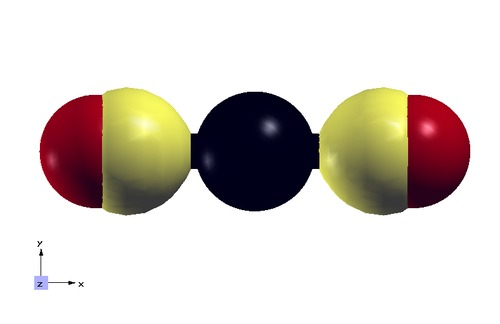
</figure>

<a id='4-4'></a>
<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Exercise</b></span>

* Inspecting the file <b>EIGVAL.OUT</b>, plot the probability density of deeper occupied and higher unoccupied <b>MOs</b> than <b>HOMO</b> and <b>LUMO</b>, respectively. How do high unoccupied <b>MOs</b> look like?
 
* Pay attention to the pairs of degenerate states: what is the character and the spatial distribution of these orbitals? 
    
* Increase the amount of vacuum in the unit cell, by increasing the lattice vectors a, b, and c to <span style="color:red;font-weight:bold">12</span>, <span style="color:red;font-weight:bold">7</span>, and <span style="color:red;font-weight:bold">7</span> Bohr, respectively. Is there an influence on the <b>MOs</b>? What happens in particular to the empty states?
    
* Visualize the <b>HOMO</b> and <b>LUMO</b> for the water and pyridine molecule, too.
</div>

<hr style="border:2px solid #DDD"> </hr>